# Analysis of Image Enhancement Methods in Low Brightness Images

In this example, an image with low brightness is analyzed.

In such images, the main problem is not always **low Contrast**.  
The image may contain both dark and bright regions, but the overall image appears darker compared to the natural scene.

The goal of this experiment is to investigate the performance of:

- Histogram Stretching
- Histogram Equalization
- CLAHE
- Brightness Adjustment

and analyze their limitations.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv2.cvtColor(cv2.imread('lowlightroom.jpg'),cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

## Display Original Image

The original image is displayed.

In this image:

- Bright regions are present.
- Dark regions are also present.

Therefore, the image contains a reasonable range of brightness values.

The main issue is related to **low Brightness** rather than a significant lack of Contrast.

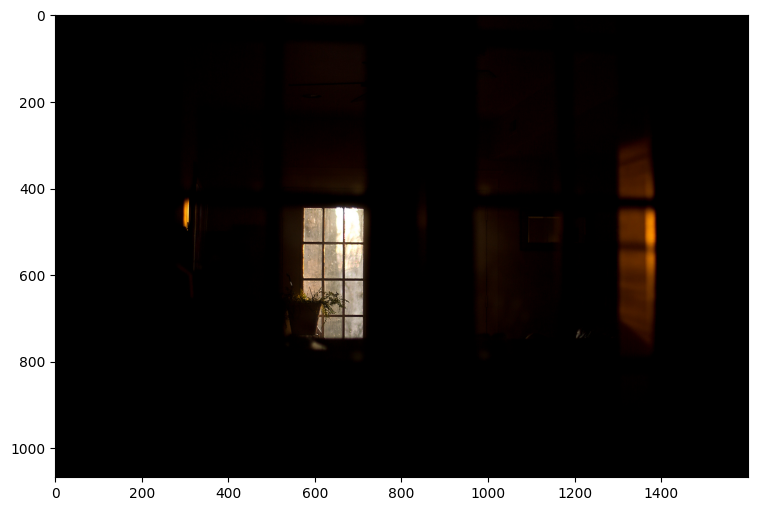

In [4]:
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.show()

In [5]:

print("max:" ,img_hsv.max())
print("min:" ,img_hsv.min())

max: 255
min: 0


In [6]:
h,s,v = cv2.split(img_hsv)

## Brightness Histogram

The histogram of the **V channel** shows the distribution of brightness values in the image.

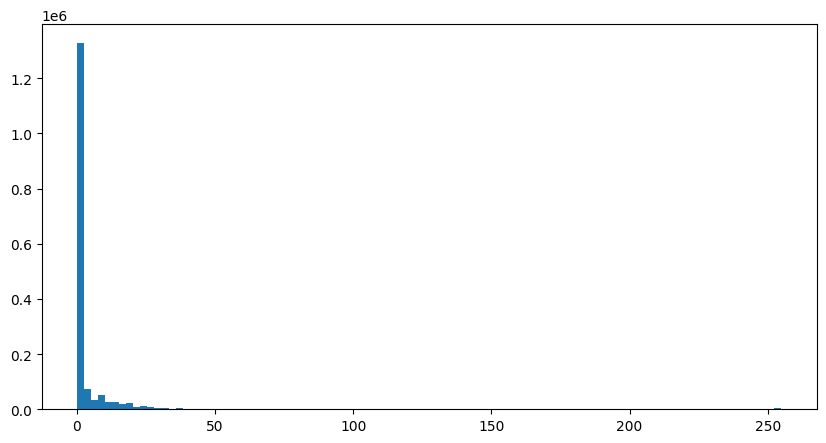

In [7]:
plt.figure(figsize=(10,5))
plt.hist(v.reshape(-1),bins=100)
plt.show()



In this image, a large number of pixels are located in the darker intensity range, but bright intensity values are also present.

Therefore, the main issue is:

**Low Brightness**

rather than the image lacking a sufficient range of brightness values.

## Function for HSV Display


In [8]:
def img_hsv_show(img_hsv):
    img_show = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
    plt.imshow(img_show)
    print(f'image shape: {img_show.shape}')
    plt.show()

## Histogram Stretching on V Channel


In [9]:
i_min = v.min()
i_max = v.max()
v_stretched = ((v - i_min) / (i_max - i_min) * 255).astype('uint8')
img_stretched = cv2.merge([h,s,v_stretched])

image shape: (1067, 1600, 3)


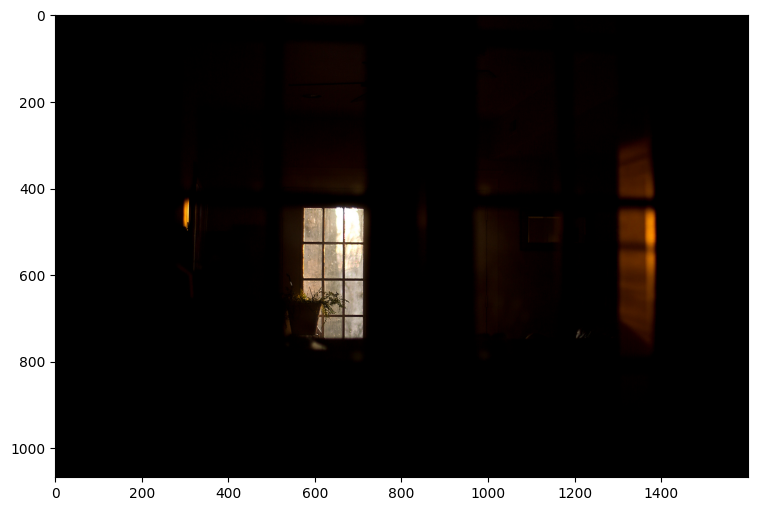

In [10]:
plt.figure(figsize=(12,6))
img_hsv_show(img_stretched)

## Result of Stretching

In this image, Histogram Stretching does not produce a significant visual improvement.

The reason is that the image already contains a range of dark and bright intensity values.

Therefore, Stretching does not have much potential to increase the Contrast.

As a result, the main issue of the image, which is **low Brightness**, is not resolved.

## Stretching on RGB Channels

In this method, Histogram Stretching is applied separately to the **R, G, and B** channels.

However, it should be noted that the main issue in this image is not related to color.

The colors are already natural, and directly processing the RGB channels may alter the relationship between color channels and affect the original color composition.

In [11]:
# color image
streched_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    i_min = ch.min()
    i_max = ch.max()
    ch_stretched = ((ch - i_min) / (i_max - i_min) * 255).astype('uint8')
    streched_channels.append(ch_stretched)

img_rgb_stretched = cv2.merge(streched_channels)

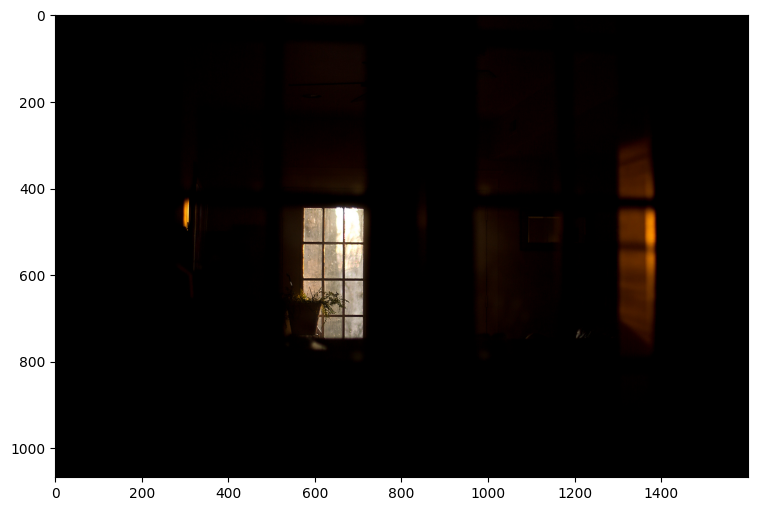

In [12]:
plt.figure(figsize=(12,6))
plt.imshow(img_rgb_stretched)
plt.show()

## Result

No significant visual improvement is observed.

This is because the main issue in the image is not related to color distortion or low Contrast.

Additionally, applying Stretching independently to the RGB channels may change the relationship between color channels and affect the original color composition in some images.

## Histogram Equalization on V Channel

Histogram Equalization attempts to make the intensity distribution of the Histogram more uniform.

This method is commonly used to enhance the Contrast of images with a narrow intensity distribution.

In this experiment, Equalization is applied only to the **V channel** to preserve the original color information.

In [13]:
v_equ = cv2.equalizeHist(v)
img_hsv_equ = cv2.merge([h,s,v_equ])

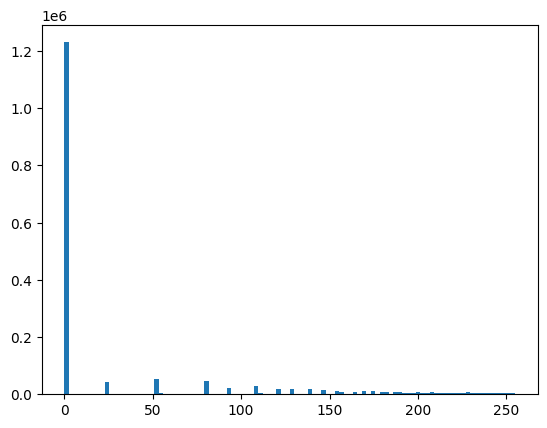

In [14]:
plt.hist(v_equ.reshape(-1),bins=100)
plt.show()

image shape: (1067, 1600, 3)


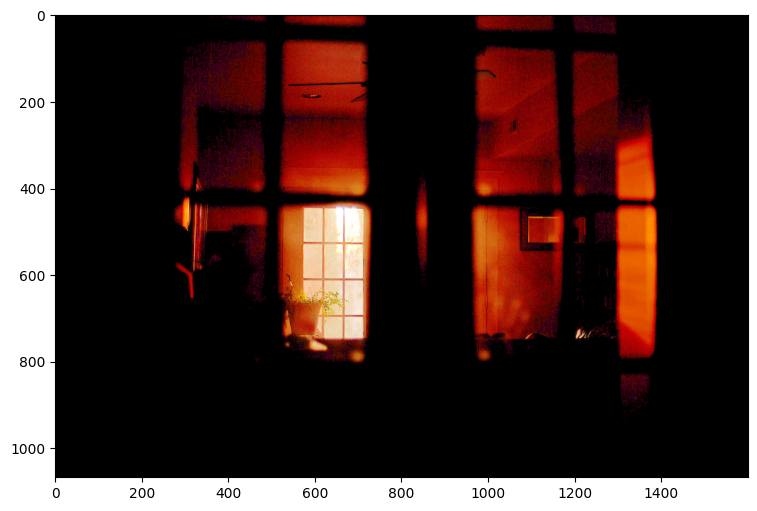

In [15]:
plt.figure(figsize=(12,6))
img_hsv_show(img_hsv_equ)

## Result of Equalization

Equalization significantly increases the variation of brightness values.

However, the result is not natural in this image.

The reason is that:

- The main issue of the image is not low Contrast.
- The image suffers from low Brightness.

Therefore, Histogram Equalization may produce an exaggerated result and make the image less realistic.

## CLAHE (Contrast Limited Adaptive Histogram Equalization) on RGB  

CLAHE is an improved version of Histogram Equalization.

The main differences are:

- **Histogram Equalization** processes the entire image globally.
- **CLAHE** divides the image into small regions and performs enhancement locally.

Therefore, CLAHE can better preserve and enhance local details while preventing excessive Contrast amplification.

In [16]:
chlahe_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    clahe = cv2.createCLAHE(clipLimit=3,tileGridSize=(8,8))
    clahe_ch = clahe.apply(ch)
    chlahe_channels.append(clahe_ch)

img_rgb_clahe = cv2.merge(chlahe_channels)

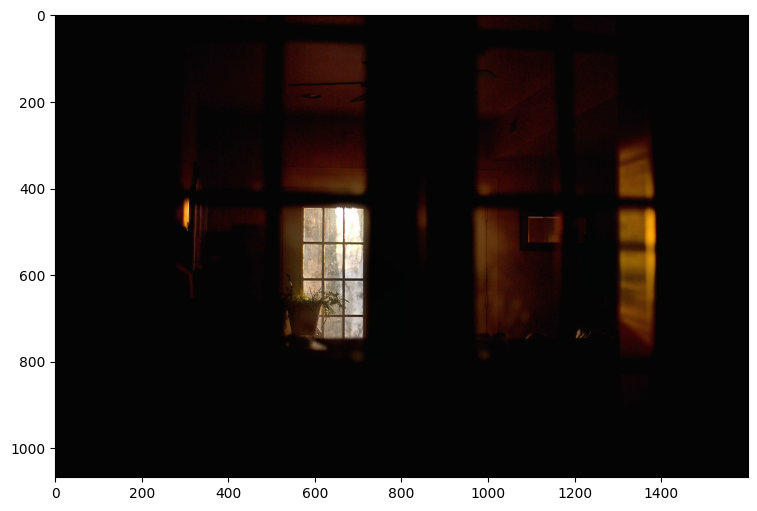

In [17]:
plt.figure(figsize=(12,6))
plt.imshow(img_rgb_clahe)
plt.show()

## Result of CLAHE

CLAHE produces a more natural result compared to the previous methods.

This is because it enhances the **local Contrast** of the image.

However, it should be noted that:

CLAHE is mainly designed to improve **Contrast**, not to directly increase **Brightness**.

Therefore, the overall brightness of the image may not increase significantly.

## Direct Brightness Increase

A simple method to increase image brightness is to add a constant value to all pixels.

$$
I_{new}=I+\beta$$

This operation increases the overall Brightness of the image.

---

## Limitation

If a large value is added to the image, the intensity range may exceed the valid pixel range.

For example:

Before:
0 - 255

After adding 50:
50 -305


Values greater than 255 are clipped.

As a result:

- Information in bright regions may be lost.
- Some areas of the image become saturated.
- The Contrast of the image is also affected.

Therefore, direct Brightness adjustment is not always the best solution.

# Linear Correction

Linear Correction is a simple image enhancement technique that simultaneously controls **Contrast** and **Brightness** using the following equation:

$$
I'=\alpha I+\beta
$$

where

- **α** controls the Contrast.
- **β** controls the Brightness.

OpenCV provides the function `cv2.convertScaleAbs()` to perform this operation efficiently.

In [28]:
alpha = 2  # Contrast coefficient
beta = 0   # Brightness coefficient
img_adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

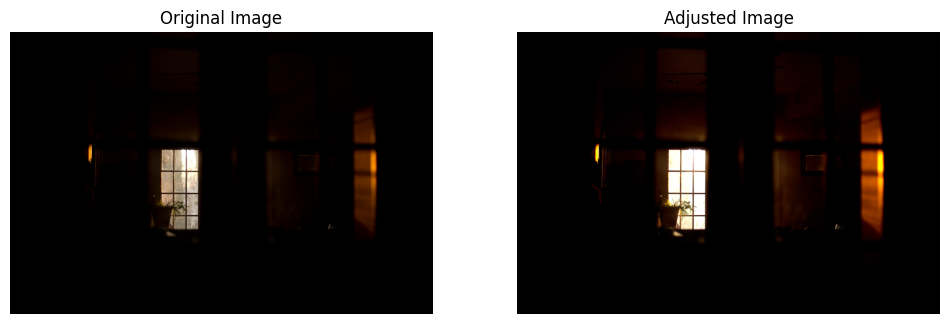

In [29]:
plt.figure(figsize=(12,6))

# Original Image
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Adjusted Image
plt.subplot(1,2,2)
plt.imshow(img_adjusted)
plt.title("Adjusted Image")
plt.axis("off")

plt.show()

## Result

Increasing **α** makes the image brighter by expanding the intensity range.

However, this approach has several limitations.

Bright pixels are multiplied by the same factor as dark pixels.

Consequently, high intensity values quickly exceed the valid range and are clipped to 255.

As a result:

- Bright regions become saturated.
- Fine details in highlighted areas are lost.
- The image may appear overexposed.

For example, details visible through the window in the original image disappear after applying a large value of **α**.

# Gamma Correction

Unlike Linear Correction, Gamma Correction performs a **nonlinear transformation** of image intensities.

The transformation is defined as

$$
I' = I^\gamma
$$

where the image is first normalized to the range [0,1].

Unlike linear scaling, Gamma Correction does not change all intensity values by the same amount.

Instead, darker and brighter pixels are adjusted differently, making it particularly effective for correcting images with improper exposure.

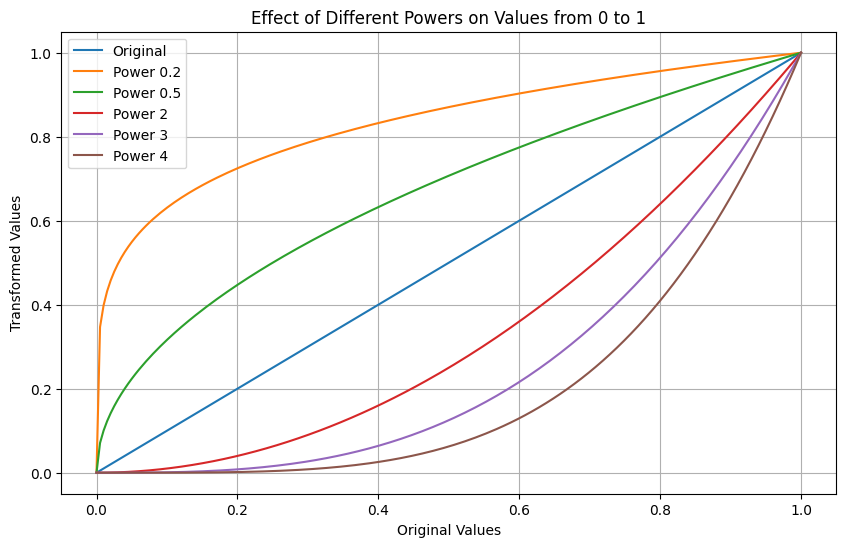

In [26]:
# gamma effect
values = np.linspace(0, 1, 200)

plt.figure(figsize=(10, 6))

plt.plot(values, values, label='Original')

powers = [0.2,0.5, 2, 3, 4]
for p in powers:
    plt.plot(values, np.power(values, p), label=f'Power {p}')

plt.title('Effect of Different Powers on Values from 0 to 1')
plt.xlabel('Original Values')
plt.ylabel('Transformed Values')
plt.legend()
plt.grid(True)

plt.show()

The curves above illustrate how different values of **γ** affect pixel intensities.

- **γ = 1** leaves the image unchanged.
- **γ < 1** increases low intensity values more than high intensity values, producing a brighter image.
- **γ > 1** suppresses low intensity values, resulting in a darker image.

Because the transformation is nonlinear, it preserves highlight details much better than Linear Correction.

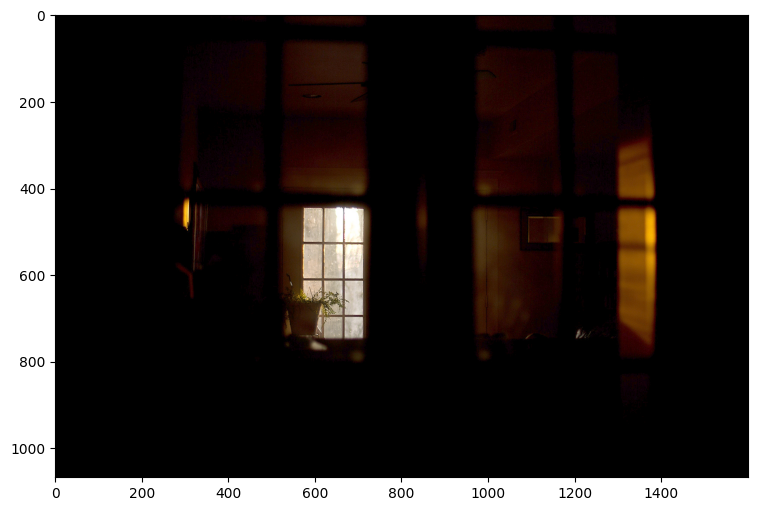

In [27]:
img_normalized = img / 255.0

gamma = 0.6
img_gamma_corrected = (np.power(img_normalized, gamma) * 255).astype('uint8')


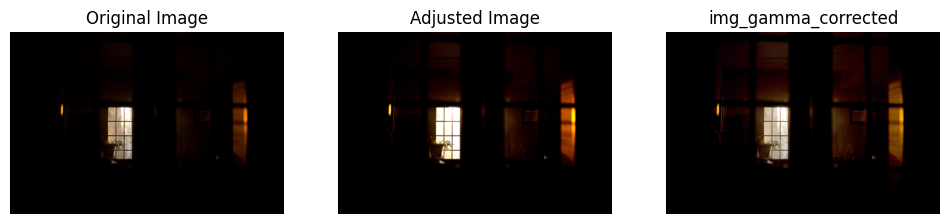

In [31]:
plt.figure(figsize=(12,6))


# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Adjusted Image
plt.subplot(1,3,2)
plt.imshow(img_adjusted)
plt.title("Adjusted Image")
plt.axis("off")

# Adjusted Image
plt.subplot(1,3,3)
plt.imshow(img_gamma_corrected)
plt.title("img_gamma_corrected")
plt.axis("off")

plt.show()

## Result

Compared with Linear Correction, Gamma Correction produces a more natural enhancement.

Dark regions become brighter while bright regions are less likely to be saturated.

As a result, more image details are preserved, especially in high intensity areas such as the window, where Linear Correction tends to lose information due to clipping.